# Разведочный анализ данных: MNIST (изображения)

Базовый EDA для датасета MNIST (файл `t10k-images.idx3-ubyte`): просмотр примеров изображений и усреднённого изображения.


In [1]:
import os
import struct
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = os.path.join("..", "datasets", "mnist")
# Используем тренировочные файлы, которые точно есть
IMAGES_PATH = os.path.join(DATA_DIR, "train-images-idx3-ubyte")
LABELS_PATH = os.path.join(DATA_DIR, "train-labels-idx1-ubyte")

def load_mnist_images(path, max_images=1000):
    with open(path, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        assert magic == 2051
        num = min(num, max_images)
        buf = f.read(rows * cols * num)
        data = np.frombuffer(buf, dtype=np.uint8)
        data = data.reshape(num, rows, cols)
    return data

def load_mnist_labels(path, max_labels=1000):
    with open(path, "rb") as f:
        magic, num = struct.unpack(">II", f.read(8))
        assert magic == 2049
        num = min(num, max_labels)
        buf = f.read(num)
        labels = np.frombuffer(buf, dtype=np.uint8)
    return labels

max_samples = 2000
images = load_mnist_images(IMAGES_PATH, max_images=max_samples)
labels = load_mnist_labels(LABELS_PATH, max_labels=max_samples)

# Обрезаем до общего размера (на всякий случай)
n = min(len(images), len(labels))
images, labels = images[:n], labels[:n]

print("Форма массива изображений:", images.shape)
print("Количество меток:", labels.shape[0])


Форма массива изображений: (2000, 28, 28)
Количество меток: 2000


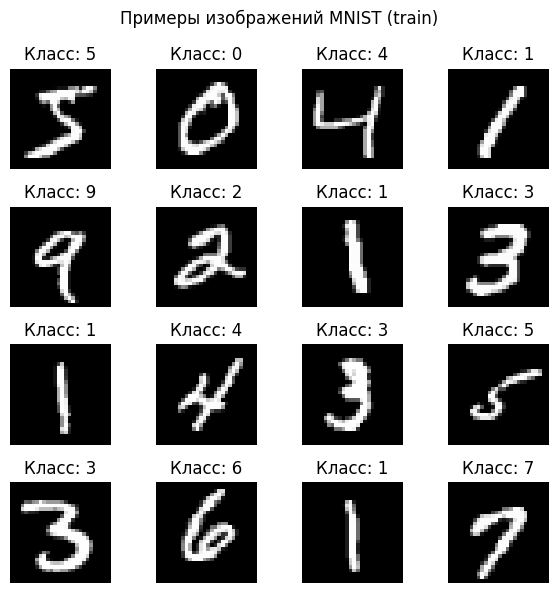

In [2]:
# --- Примеры с подписями ---
plt.figure(figsize=(6, 6))
for i in range(1, 17):
    plt.subplot(4, 4, i)
    plt.imshow(images[i-1], cmap="gray")
    plt.title(f"Класс: {labels[i-1]}")
    plt.axis("off")
plt.suptitle("Примеры изображений MNIST (train)")
plt.tight_layout()
plt.show()

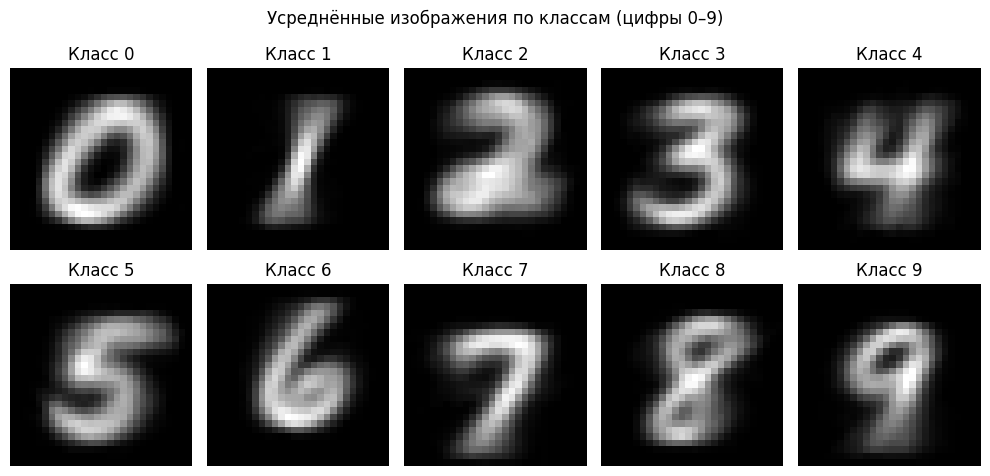

In [3]:
# --- Усреднённые по классам ---
mean_per_class = []
for digit in range(10):
    class_imgs = images[labels == digit]
    mean_img = class_imgs.mean(axis=0) if len(class_imgs) > 0 else np.zeros_like(images[0])
    mean_per_class.append(mean_img)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()
for digit in range(10):
    axes[digit].imshow(mean_per_class[digit], cmap="gray")
    axes[digit].set_title(f"Класс {digit}")
    axes[digit].axis("off")
plt.suptitle("Усреднённые изображения по классам (цифры 0–9)")
plt.tight_layout()
plt.show()

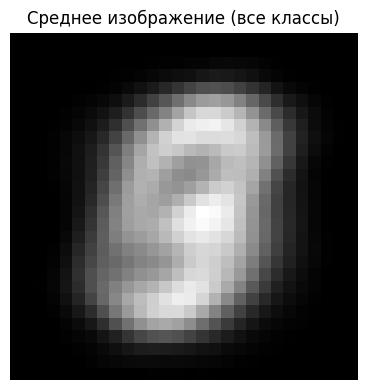

In [4]:
# --- Среднее по всем ---
mean_all = images.mean(axis=0)
plt.figure(figsize=(4, 4))
plt.imshow(mean_all, cmap="gray")
plt.title("Среднее изображение (все классы)")
plt.axis("off")
plt.tight_layout()
plt.show()

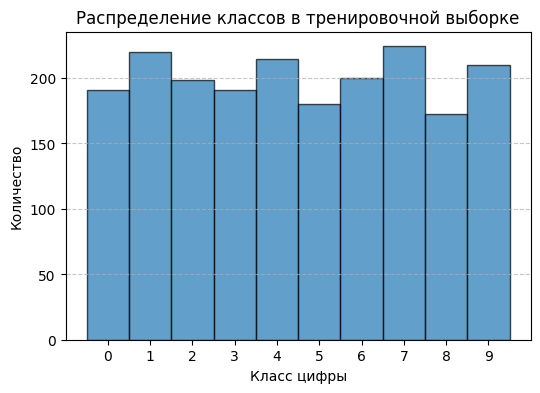

In [5]:
# --- Распределение классов ---
plt.figure(figsize=(6, 4))
plt.hist(labels, bins=np.arange(11)-0.5, edgecolor='black', alpha=0.7)
plt.xticks(range(10))
plt.xlabel("Класс цифры")
plt.ylabel("Количество")
plt.title("Распределение классов в тренировочной выборке")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()